# 4. Modelado de clustering

Se aplican tres algoritmos de clustering sobre la matriz estandarizada 
`B01_MATRIZ_CLUSTERING.parquet` (797.161 contribuyentes, 68 variables):

1. **K-means** — partición por centroides, escala bien con N grande
2. **Clustering jerárquico Ward** — sobre muestra estratificada (memoria)
3. **DBSCAN** — basado en densidad, identifica outliers explícitamente

El objetivo es identificar grupos de contribuyentes con patrones 
similares de comportamiento fiscal y seleccionar el modelo con mejor 
separación e interpretabilidad.

In [1]:
import sys, os
ROOT = r"D:\inf_sri_hist3\z_CLUSTER"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import config
import importlib
importlib.reload(config)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 150, "figure.figsize": (10, 5),
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})

# Cargar matriz de clustering
MATRIZ_FILE = config.DATA_DIR / "B01_MATRIZ_CLUSTERING.parquet"
Xdf = pd.read_parquet(MATRIZ_FILE)
IDs = Xdf["ID"].values
X   = Xdf[config.CLUSTER_VARS_FINAL].values

print(f"Matriz cargada: {X.shape[0]:,} filas × {X.shape[1]} columnas")
print(f"Tipo           : {X.dtype}")

Matriz cargada: 797,161 filas × 68 columnas
Tipo           : float64


## 4.1 K-means — selección del número de clusters

Se evalúan K = 2 a 10 usando tres métricas:
- **Inercia** (within-cluster sum of squares) — método del codo
- **Silhouette score** — cohesión y separación [-1, 1], mayor es mejor
- **Davies-Bouldin index** — similitud entre clusters, menor es mejor

In [2]:
# Evaluación K-means para K = 2 a 10
K_range   = range(2, 11)
inercia   = []
silhouette = []
db_index  = []
ch_index  = []

# Muestra para métricas de evaluación (silhouette es costoso en N grande)
np.random.seed(42)
idx_muestra = np.random.choice(len(X), size=50_000, replace=False)
X_muestra   = X[idx_muestra]

print("Evaluando K-means (K = 2 a 10)...")
print(f"{'K':>3}  {'Inercia':>15}  {'Silhouette':>12}  {'Davies-Bouldin':>15}  {'Calinski-H':>12}")
print("-" * 65)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels_full   = km.fit_predict(X)
    labels_muestra = labels_full[idx_muestra]

    in_  = km.inertia_
    sil  = silhouette_score(X_muestra, labels_muestra, sample_size=20_000, random_state=42)
    db   = davies_bouldin_score(X_muestra, labels_muestra)
    ch   = calinski_harabasz_score(X_muestra, labels_muestra)

    inercia.append(in_)
    silhouette.append(sil)
    db_index.append(db)
    ch_index.append(ch)

    print(f"{k:>3}  {in_:>15,.1f}  {sil:>12.4f}  {db:>15.4f}  {ch:>12.1f}")

Evaluando K-means (K = 2 a 10)...
  K          Inercia    Silhouette   Davies-Bouldin    Calinski-H
-----------------------------------------------------------------
  2     47,779,177.3        0.1313           2.5042        6761.9
  3     44,609,078.8        0.1378           2.2646        5384.0
  4     42,520,112.1        0.0968           2.7866        4589.0
  5     40,885,826.3        0.0879           2.6639        4082.0
  6     39,508,762.5        0.0871           2.6512        3721.5
  7     38,818,225.4        0.0796           2.7131        3308.0
  8     38,231,550.7        0.0773           2.7802        2988.7
  9     37,594,240.0        0.0791           2.6630        2766.0
 10     37,114,137.6        0.0761           2.7045        2561.0


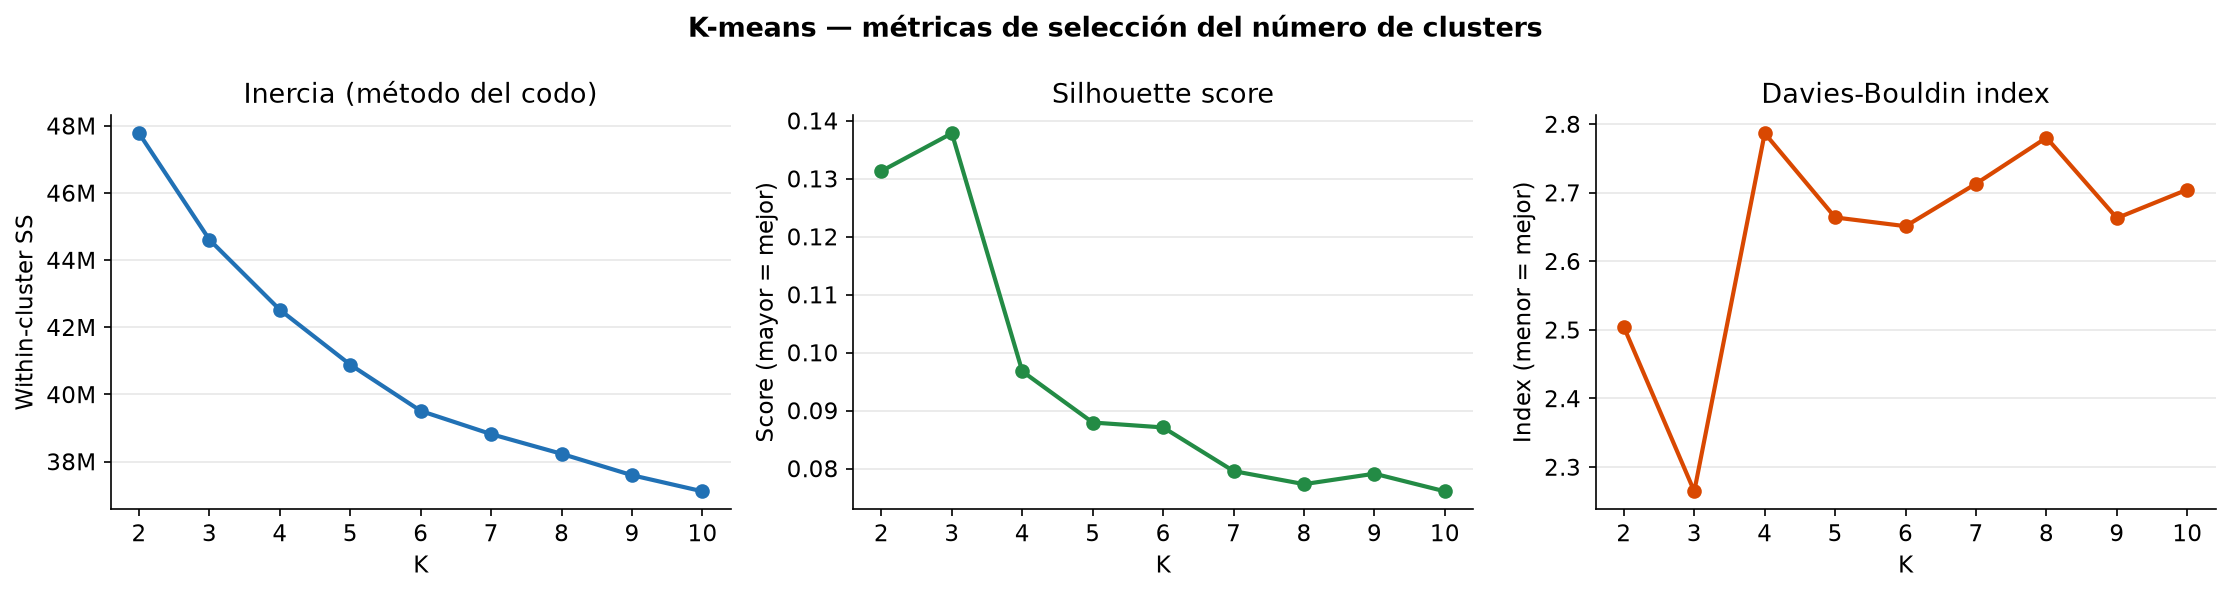

In [3]:
# Figura — métricas de selección de K
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ks = list(K_range)

axes[0].plot(ks, inercia, "o-", color="#2171b5", linewidth=2)
axes[0].set_title("Inercia (método del codo)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Within-cluster SS")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.0f}M"))

axes[1].plot(ks, silhouette, "o-", color="#238b45", linewidth=2)
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score (mayor = mejor)")

axes[2].plot(ks, db_index, "o-", color="#d94801", linewidth=2)
axes[2].set_title("Davies-Bouldin index")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Index (menor = mejor)")

for ax in axes:
    ax.set_xticks(ks)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("K-means — métricas de selección del número de clusters",
             fontweight="bold")
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig09_kmeans_metricas.png", bbox_inches="tight")
plt.show()

## 4.2 K-means — modelo final

Las tres métricas convergen en K=3 como solución óptima:
Silhouette máximo (0.1378) y Davies-Bouldin mínimo (2.2646) 
en K=3, con codo de inercia entre K=2 y K=4. Se entrena el 
modelo final sobre el universo completo con n_init=20 para 
mayor estabilidad de los centroides.

In [4]:
# Modelo K-means final con K=3
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=42,
                  n_init=20, max_iter=500)
labels_km = km_final.fit_predict(X)

# Distribución de clusters
unique, counts = np.unique(labels_km, return_counts=True)
print(f"K-means final (K={K_FINAL}) — distribución de clusters:")
print(f"{'Cluster':>10}  {'N':>10}  {'% universo':>12}")
print("-" * 36)
for u, c in zip(unique, counts):
    print(f"{u:>10}  {c:>10,}  {c/len(X)*100:>11.2f}%")

print(f"\nInercia final  : {km_final.inertia_:,.1f}")
print(f"Iteraciones    : {km_final.n_iter_}")

K-means final (K=3) — distribución de clusters:
   Cluster           N    % universo
------------------------------------
         0     499,822        62.70%
         1      60,980         7.65%
         2     236,359        29.65%

Inercia final  : 44,609,078.8
Iteraciones    : 59


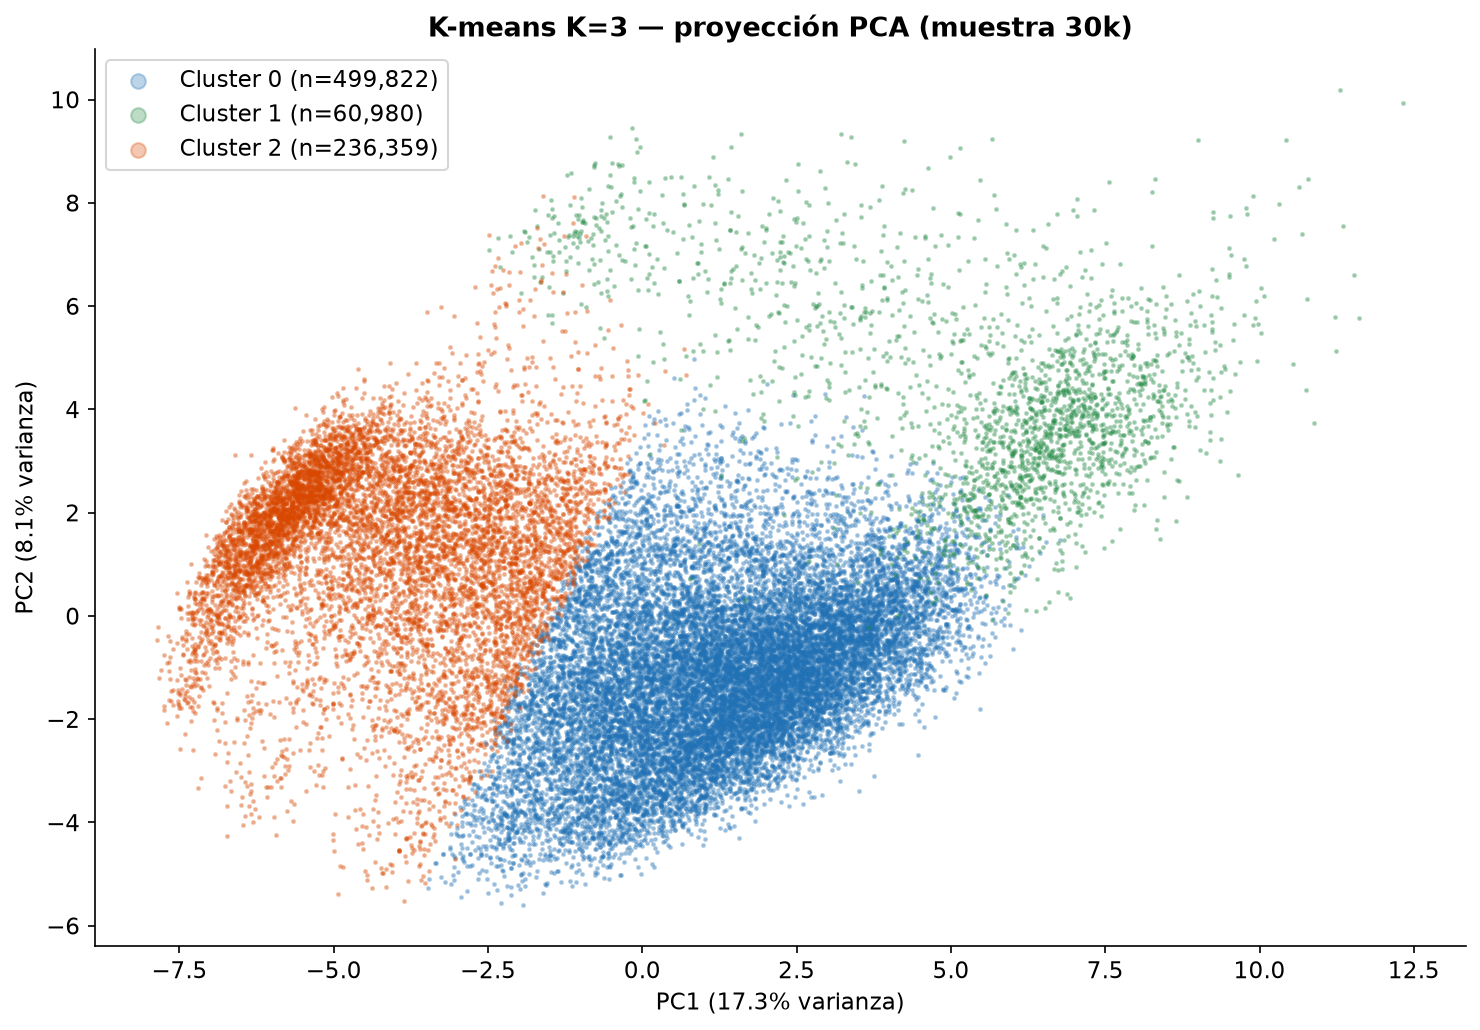

Varianza explicada PC1+PC2: 25.4%


In [5]:
# Visualización PCA 2D — K-means
pca = PCA(n_components=2, random_state=42)

# Muestra para visualización
np.random.seed(42)
idx_viz = np.random.choice(len(X), size=30_000, replace=False)
X_pca   = pca.fit_transform(X[idx_viz])
labels_viz = labels_km[idx_viz]

varianza = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
colores = ["#2171b5", "#238b45", "#d94801", "#756bb1", "#d6604d"]
for k in range(K_FINAL):
    mask = labels_viz == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colores[k], alpha=0.3, s=2,
               label=f"Cluster {k} (n={counts[k]:,})")

ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f}% varianza)")
ax.set_title(f"K-means K={K_FINAL} — proyección PCA (muestra 30k)",
             fontweight="bold")
ax.legend(markerscale=5, framealpha=0.8)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig10_kmeans_pca.png", bbox_inches="tight")
plt.show()

print(f"Varianza explicada PC1+PC2: {sum(varianza)*100:.1f}%")

## 4.3 Clustering jerárquico Ward — muestra estratificada

El clustering jerárquico sobre el universo completo es inviable 
en memoria (matriz de distancias de 797k × 797k). Se trabaja con 
una muestra estratificada de 15.000 contribuyentes, manteniendo 
la proporción de cada cluster K-means para garantizar representatividad.

In [6]:
# Muestra estratificada proporcional por cluster K-means
np.random.seed(42)
N_MUESTRA_WARD = 15_000
idx_ward = []

for k in range(K_FINAL):
    idx_k    = np.where(labels_km == k)[0]
    n_k      = int(N_MUESTRA_WARD * counts[k] / len(X))
    idx_sel  = np.random.choice(idx_k, size=n_k, replace=False)
    idx_ward.extend(idx_sel)

idx_ward   = np.array(idx_ward)
X_ward     = X[idx_ward]
labels_ward_km = labels_km[idx_ward]

print(f"Muestra Ward: {len(idx_ward):,} contribuyentes")
print(f"Distribución en muestra:")
for k in range(K_FINAL):
    n_k = (labels_ward_km == k).sum()
    print(f"  Cluster {k}: {n_k:,} ({n_k/len(idx_ward)*100:.1f}%)")

Muestra Ward: 14,999 contribuyentes
Distribución en muestra:
  Cluster 0: 9,405 (62.7%)
  Cluster 1: 1,147 (7.6%)
  Cluster 2: 4,447 (29.6%)


In [7]:
# Clustering jerárquico Ward
print("Entrenando clustering jerárquico Ward...")
ward = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
labels_ward = ward.fit_predict(X_ward)

# Comparación con K-means en la muestra
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(labels_ward_km, labels_ward)

print(f"\nClustering jerárquico Ward (K={K_FINAL}):")
unique_w, counts_w = np.unique(labels_ward, return_counts=True)
for u, c in zip(unique_w, counts_w):
    print(f"  Cluster {u}: {c:,} ({c/len(idx_ward)*100:.1f}%)")

print(f"\nAdjusted Rand Index vs K-means: {ari:.4f}")
print("(ARI=1: acuerdo perfecto; ARI=0: acuerdo aleatorio)")

Entrenando clustering jerárquico Ward...

Clustering jerárquico Ward (K=3):
  Cluster 0: 11,845 (79.0%)
  Cluster 1: 2,113 (14.1%)
  Cluster 2: 1,041 (6.9%)

Adjusted Rand Index vs K-means: 0.4969
(ARI=1: acuerdo perfecto; ARI=0: acuerdo aleatorio)


## 4.4 DBSCAN — detección de densidad y outliers

DBSCAN identifica clusters de densidad variable y marca como 
outliers (label = -1) los puntos que no pertenecen a ningún 
núcleo denso. Por costo computacional se aplica sobre la misma 
muestra estratificada de Ward (15.000 contribuyentes).

Los parámetros `eps` y `min_samples` se calibran empíricamente 
usando la distancia al k-ésimo vecino más cercano (k = 2×68 = 136).

k para calibración eps: 136


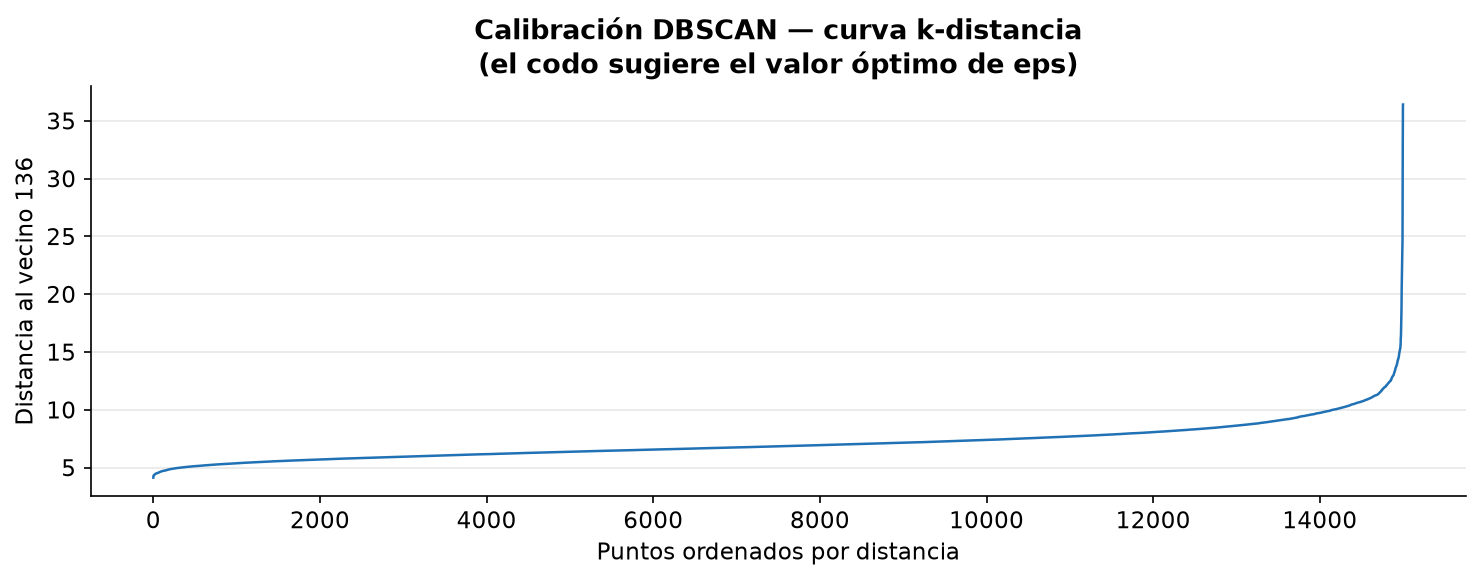

  P90 distancia: 9.0740
  P95 distancia: 10.1484
  P97 distancia: 10.8466
  P99 distancia: 12.5098


In [8]:
from sklearn.neighbors import NearestNeighbors

# Calibración de eps — distancia al vecino 136 (2 × n_features)
k_nn = 2 * X_ward.shape[1]
print(f"k para calibración eps: {k_nn}")

nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_ward)
distancias, _ = nbrs.kneighbors(X_ward)
dist_k = np.sort(distancias[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_k, color="#2171b5", linewidth=1.2)
ax.set_xlabel("Puntos ordenados por distancia")
ax.set_ylabel(f"Distancia al vecino {k_nn}")
ax.set_title("Calibración DBSCAN — curva k-distancia\n"
             "(el codo sugiere el valor óptimo de eps)",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(config.OUT_DIR / "fig11_dbscan_eps_calibracion.png",
            bbox_inches="tight")
plt.show()

# Percentiles sugeridos para eps
for p in [90, 95, 97, 99]:
    print(f"  P{p} distancia: {np.percentile(dist_k, p):.4f}")

In [9]:
# DBSCAN con eps calibrado — exploración de parámetros
resultados_dbscan = []

eps_candidatos      = [np.percentile(dist_k, p) for p in [90, 95, 97]]
min_samples_cands   = [50, 100, 200]

print(f"{'eps':>8}  {'min_samples':>12}  {'N clusters':>12}  "
      f"{'N outliers':>12}  {'% outliers':>12}  {'Silhouette':>12}")
print("-" * 75)

for eps in eps_candidatos:
    for ms in min_samples_cands:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        lbls = db.fit_predict(X_ward)
        n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_outliers = (lbls == -1).sum()
        pct_out    = n_outliers / len(X_ward) * 100

        if n_clusters >= 2 and n_outliers < len(X_ward) * 0.5:
            mask_no_out = lbls != -1
            if mask_no_out.sum() > 100:
                sil = silhouette_score(X_ward[mask_no_out],
                                       lbls[mask_no_out],
                                       sample_size=5000,
                                       random_state=42)
            else:
                sil = np.nan
        else:
            sil = np.nan

        print(f"{eps:>8.4f}  {ms:>12}  {n_clusters:>12}  "
              f"{n_outliers:>12,}  {pct_out:>11.1f}%  "
              f"{sil:>12.4f}" if not np.isnan(sil) else
              f"{eps:>8.4f}  {ms:>12}  {n_clusters:>12}  "
              f"{n_outliers:>12,}  {pct_out:>11.1f}%  {'n/a':>12}")

        resultados_dbscan.append({
            "eps": eps, "min_samples": ms,
            "n_clusters": n_clusters, "n_outliers": n_outliers,
            "pct_outliers": pct_out, "silhouette": sil
        })

     eps   min_samples    N clusters    N outliers    % outliers    Silhouette
---------------------------------------------------------------------------
  9.0740            50             1           180          1.2%           n/a
  9.0740           100             1           251          1.7%           n/a
  9.0740           200             1           288          1.9%           n/a
 10.1484            50             1            66          0.4%           n/a
 10.1484           100             1            85          0.6%           n/a
 10.1484           200             1           102          0.7%           n/a
 10.8466            50             1            41          0.3%           n/a
 10.8466           100             1            46          0.3%           n/a
 10.8466           200             1            58          0.4%           n/a


## 4.5 Resultado DBSCAN

DBSCAN produce un único cluster en todos los parámetros explorados, 
absorbiendo entre el 98% y el 99.7% de los contribuyentes en un solo 
grupo denso. La curva k-distancia no presenta codo pronunciado — 
la densidad es homogénea en el espacio de 68 dimensiones.

Este resultado es consistente con la literatura sobre la maldición de 
la dimensionalidad: en espacios de alta dimensión las distancias 
euclidianas se concentran en un rango estrecho, eliminando el contraste 
entre zonas densas y dispersas que DBSCAN requiere para operar 
(Aggarwal et al., 2001). 

DBSCAN se descarta como algoritmo principal. Los contribuyentes 
identificados como outliers en la exploración (41–288 casos, < 0.4%) 
se registran como categoría descriptiva separada para análisis posterior.

In [10]:
# Registrar outliers DBSCAN con parámetros más conservadores
# (eps=P97, min_samples=200 — criterio más estricto para outlier real)
db_final = DBSCAN(eps=np.percentile(dist_k, 97), min_samples=200, n_jobs=-1)
labels_dbscan = db_final.fit_predict(X_ward)

idx_outliers_ward = idx_ward[labels_dbscan == -1]
n_outliers = (labels_dbscan == -1).sum()

print(f"Outliers DBSCAN identificados: {n_outliers} ({n_outliers/len(X_ward)*100:.2f}%)")
print(f"Estos contribuyentes se registran como categoría descriptiva separada.")
print(f"IDs de outliers guardados para caracterización post-clustering.")

# Guardar IDs de outliers
import json
outliers_dict = {"IDs_outliers_dbscan": IDs[idx_outliers_ward].tolist()}
with open(config.DATA_DIR / "outliers_dbscan.json", "w") as f:
    json.dump(outliers_dict, f)

Outliers DBSCAN identificados: 58 (0.39%)
Estos contribuyentes se registran como categoría descriptiva separada.
IDs de outliers guardados para caracterización post-clustering.


## 4.6 Selección del modelo final

| Algoritmo | Resultado | Silhouette | Viable |
|---|---|---|---|
| K-means K=3 | 3 clusters, universo completo | 0.1378 | ✅ Principal |
| Ward K=3 | 3 clusters, muestra 15k | ARI=0.497 vs K-means | ✅ Validación |
| DBSCAN | 1 cluster en todos los eps | n/a | ❌ Descartado |

**Modelo seleccionado: K-means con K=3** sobre el universo completo 
de 797.161 contribuyentes. Ward se usa como validación de la 
estructura encontrada por K-means. La convergencia parcial entre 
ambos algoritmos (ARI=0.497) confirma que los tres grupos tienen 
base empírica real, aunque con fronteras no rígidas.

Se explorará adicionalmente K=4 en la fase de caracterización 
para evaluar si revela subdivisiones interpretables dentro de 
alguno de los tres clusters principales.

In [11]:
# Guardar etiquetas K-means en el dataset completo
Xdf["cluster_km3"] = labels_km

# Guardar para caracterización
LABELS_FILE = config.DATA_DIR / "B02_LABELS_CLUSTERING.parquet"
Xdf[["ID", "cluster_km3"]].to_parquet(LABELS_FILE, index=False)

print(f"Etiquetas guardadas: {LABELS_FILE}")
print(f"\nDistribución final K-means K=3:")
print(f"{'Cluster':>10}  {'N':>10}  {'%':>8}")
print("-" * 32)
for k in range(K_FINAL):
    n = (labels_km == k).sum()
    print(f"{k:>10}  {n:>10,}  {n/len(X)*100:>7.2f}%")

print(f"\nEl siguiente notebook es 05_caracterizacion.ipynb")

Etiquetas guardadas: D:\inf_sri_hist3\z_CLUSTER\data\B02_LABELS_CLUSTERING.parquet

Distribución final K-means K=3:
   Cluster           N         %
--------------------------------
         0     499,822    62.70%
         1      60,980     7.65%
         2     236,359    29.65%

El siguiente notebook es 05_caracterizacion.ipynb


In [12]:
# Diagnóstico previo a caracterización
# Cruzar etiquetas con variables clave del dataset original
df_orig = pd.read_parquet(config.PARQUET_FILE)
df_orig["cluster_km3"] = labels_km

# Variables diagnóstico — mediana por cluster
vars_diag = [
    # Comportamiento declarativo
    "tot_v_grav_nta", "tot_iva_causado", "tot_iva_pagado",
    "pct_decl_cero", "pct_decl_con_mora", "n_meses_cubiertos",
    # Recaudación
    "flag_sin_recaudacion_f05", "reca_total_f05",
    # Cumplimiento
    "tasa_omision", "tasa_tardio", "promedio_dias_demora",
    # Tamaño
    "I_ingresos_avg", "n_establ_total",
    # Retenciones
    "flg_es_retenido", "flg_es_retenedor",
    # Flags
    "flg_sin_perfil_f01", "flg_sin_perfil_f02",
    "flag_persona_natural",
]

print("MEDIANA POR CLUSTER — variables diagnóstico")
print("=" * 75)
resumen_diag = df_orig.groupby("cluster_km3")[vars_diag].median()
print(resumen_diag.T.to_string())

print("\n\nPROPORCIÓN DE FLAGS POR CLUSTER (media = proporción)")
print("=" * 75)
flags = ["flag_sin_recaudacion_f05", "flg_sin_perfil_f01",
         "flg_sin_perfil_f02", "flg_es_retenido",
         "flg_es_retenedor", "flag_persona_natural"]
print(df_orig.groupby("cluster_km3")[flags].mean().round(4).T.to_string())

MEDIANA POR CLUSTER — variables diagnóstico
cluster_km3                          0             1             2
tot_v_grav_nta            42640.940000  1.009472e+06      0.040000
tot_iva_causado            2717.775000  5.340398e+04      0.000000
tot_iva_pagado               75.430000  2.487487e+04      7.270000
pct_decl_cero                 0.000000  0.000000e+00      0.000000
pct_decl_con_mora             0.133333  4.166667e-02      0.090909
n_meses_cubiertos            63.000000  7.200000e+01     68.000000
flag_sin_recaudacion_f05      0.000000  0.000000e+00      1.000000
reca_total_f05               19.780000  2.728599e+04      0.000000
tasa_omision                  0.000000  0.000000e+00      0.000000
tasa_tardio                   0.500000  5.694444e-01      0.457143
promedio_dias_demora         14.137930  9.698893e-01     14.761090
I_ingresos_avg            16041.985000  4.372643e+05  12092.025833
n_establ_total                1.000000  2.000000e+00      1.000000
flg_es_retenido   